# Monte Carlo: устойчивость калибровок PD к составу портфеля

Проверяем, насколько результаты сравнения калибраторов зависят от конкретного сгенерированного портфеля. Логика:

- **RF и все калибраторы обучаются один раз** на полном in-time периоде 2020-2023 — внутри сценариев ничего не переобучается;
- каждый сценарий независимо берет **~80% наблюдений без возврата** отдельно из in-time и отдельно из OOT 2024;
- подвыборки прогоняются через уже готовый пайплайн `score -> calibrated PD -> EL / UL / Capital / RWA`;
- по каждому сценарию и методу считаются:
  - p-value биномиального теста на IN-TIME и на OOT — **тест модели целиком (само-калибровка)**: суммарный факт дефолтов против суммы предсказанных моделью PD. Корректно построенная, приведённая к ЦТ модель его проходит. По-грейдовая разбивка по фиксированной мастер-шкале A1…E вынесена в диагностику (раздел 3c), потому что она тестирует соответствие фиксированной шкале ментора, а не корректность самой модели;
  - средний PD на OOT;
  - Expected Loss, Unexpected Loss capital, их сумму **EL + UL** (полный экономический капитал) и RWA (те же допущения, что в разделе 8.1: EAD = 1 млн на актив, LGD = 40%, M = 2.5). Отдельная колонка Required Capital убрана: она тождественно равна UL (`required_capital = capital_ratio · RWA = UL`), поэтому вместо неё показываем EL + UL.

Итоговая таблица показывает для каждого метода **среднее, минимум, максимум и разницу max-min** — чем уже разброс, тем меньше результат зависит от случайного состава портфеля.

Вычислительный движок лежит в `notebooks/monte_carlo.py`; этот ноутбук — его отчетная обертка с таблицами и графиками.

In [1]:
import sys

for extra_path in ("..", "."):
    if extra_path not in sys.path:
        sys.path.append(extra_path)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from matplotlib.ticker import PercentFormatter

from monte_carlo import (
    METRIC_COLUMNS,
    prepare_fixed_pipeline,
    run_scenario,
    summarize_monte_carlo,
    cross_method_spread,
    summarize_cross_method_spread,
    whole_model_binomial_p_value,
)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11
COLORS = ["#e74c3c", "#2980b9", "#27ae60", "#e67e22", "#8e44ad", "#16a085"]

N_SCENARIOS = 1000
SAMPLE_FRAC = 0.8

print(f"Сценариев: {N_SCENARIOS} | доля подвыборки: {SAMPLE_FRAC:.0%}")

Сценариев: 1000 | доля подвыборки: 80%


## 1. Фиксированный пайплайн

Один раз генерируем тот же синтетический stress-портфель (random_state=42, как в основном ноутбуке), обучаем RF и все пять калибраторов на полном in-time. Дальше эти объекты не меняются.

In [2]:
pipeline = prepare_fixed_pipeline(portfolio="stress", random_state=42)

n_intime = len(pipeline["y_calib"])
n_oot = len(pipeline["y_test"])
ct_intime = float(pipeline["y_calib"].mean())
dr_oot = float(pipeline["y_test"].mean())

print(f"In-time (2020-2023): {n_intime:,} строк | ЦТ = {ct_intime:.2%}")
print(f"OOT (2024):          {n_oot:,} строк | фактическая доля дефолтов = {dr_oot:.2%}")
print(f"Размер сценарной подвыборки: ~{int(n_intime * SAMPLE_FRAC):,} in-time / ~{int(n_oot * SAMPLE_FRAC):,} OOT строк")
print(f"Методы: {', '.join(pipeline['methods'])}")
print("\nПер-строчные PD и IRB-капитал предвычислены один раз; сценарий только индексирует")
print("свою случайную ~80%-подвыборку — поэтому 1000 сценариев считаются за минуты.")

In-time (2020-2023): 31,224 строк | ЦТ = 4.81%
OOT (2024):          8,776 строк | фактическая доля дефолтов = 4.73%
Размер сценарной подвыборки: ~24,979 in-time / ~7,020 OOT строк
Методы: Логит-калибровка, Изотоническая регрессия, Бета-калибровка, Монотонный сплайн, Французский сплайн

Пер-строчные PD и IRB-капитал предвычислены один раз; сценарий только индексирует
свою случайную ~80%-подвыборку — поэтому 1000 сценариев считаются за минуты.


## 2. Прогон сценариев

Каждый сценарий использует свой seed (0..N-1), поэтому весь эксперимент воспроизводим. При 1000 сценариях таблица целиком (5000 строк) не нужна — ниже показаны первые 5 сценариев для наглядности формата, все данные лежат в `scenario_results`.

In [3]:
scenario_results = pd.concat(
    [run_scenario(pipeline, scenario_seed=seed, sample_frac=SAMPLE_FRAC) for seed in range(N_SCENARIOS)],
    ignore_index=True,
)

money_cols = ["expected_loss", "unexpected_loss_capital", "el_plus_ul", "rwa"]
scenario_view = scenario_results.copy()
for col in money_cols:
    scenario_view[col + "_bln"] = scenario_view[col] / 1e9
scenario_view = scenario_view.drop(columns=money_cols)

n_preview = 5 * scenario_results["method"].nunique()
print(f"Всего строк: {len(scenario_results)} ({N_SCENARIOS} сценариев x {scenario_results['method'].nunique()} методов)")
print(f"Ниже — первые 5 сценариев ({n_preview} строк):")
display(
    scenario_view.head(n_preview).style.format({
        "p_value_intime": "{:.6f}",
        "p_value_oot": "{:.6f}",
        "oot_mean_pd": "{:.4%}",
        "expected_loss_bln": "{:.4f}",
        "unexpected_loss_capital_bln": "{:.4f}",
        "el_plus_ul_bln": "{:.4f}",
        "rwa_bln": "{:.4f}",
    }).hide(axis="index")
)

Всего строк: 5000 (1000 сценариев x 5 методов)
Ниже — первые 5 сценариев (25 строк):


scenario,method,p_value_intime,p_value_oot,oot_mean_pd,expected_loss_bln,unexpected_loss_capital_bln,el_plus_ul_bln,rwa_bln
0,Логит-калибровка,0.635208,0.867675,4.8552%,0.1364,0.5413,0.6776,6.7658
0,Изотоническая регрессия,0.624739,0.889473,4.8438%,0.1361,0.5213,0.6573,6.5161
0,Бета-калибровка,0.635204,0.889494,4.8478%,0.1361,0.5474,0.6836,6.8426
0,Монотонный сплайн,0.645762,0.845956,4.8596%,0.1365,0.5249,0.6614,6.5619
0,Французский сплайн,0.635203,0.845947,4.8562%,0.1364,0.5249,0.6613,6.5606
1,Логит-калибровка,0.916923,0.825855,4.9548%,0.1392,0.5457,0.6848,6.8212
1,Изотоническая регрессия,0.928770,0.783537,4.9645%,0.1394,0.5263,0.6657,6.5782
1,Бета-калибровка,0.893263,0.847225,4.9469%,0.1389,0.5516,0.6906,6.8953
1,Монотонный сплайн,0.893284,0.783599,4.9699%,0.1396,0.5300,0.6696,6.6245
1,Французский сплайн,0.893275,0.783540,4.9653%,0.1395,0.5298,0.6693,6.6231


### Полная выгрузка всех сценариев

Все 1000 сценариев (5000 строк) сохраняются в `docs/monte_carlo_scenarios.csv`, чтобы с ними можно было ознакомиться отдельно — открыть в Excel или прямо на GitHub (там CSV показывается как таблица с поиском и сортировкой). Денежные метрики — в исходных единицах (рубли), `oot_mean_pd` и p-value — как доли.

In [4]:
from pathlib import Path

csv_path = Path("..") / "docs" / "monte_carlo_scenarios.csv"
export = scenario_results.sort_values(["scenario", "method"]).reset_index(drop=True)
export.to_csv(csv_path, index=False, encoding="utf-8-sig")

print(f"Сохранено {len(export)} строк ({export['scenario'].nunique()} сценариев x {export['method'].nunique()} методов)")
print(f"Файл: docs/monte_carlo_scenarios.csv")
print(f"Колонки: {', '.join(export.columns)}")

Сохранено 5000 строк (1000 сценариев x 5 методов)
Файл: docs/monte_carlo_scenarios.csv
Колонки: scenario, method, p_value_intime, p_value_oot, oot_mean_pd, expected_loss, unexpected_loss_capital, el_plus_ul, rwa


## 3. Итоговая таблица: среднее / минимум / максимум / разброс

Ключевой показатель — **range (max - min)**: он показывает, насколько сильно метрика гуляет между сценариями при неизменной модели и калибровке.

In [5]:
summary = summarize_monte_carlo(scenario_results)

metric_titles = {
    "p_value_intime": ("Min binomial p-value (мастер-шкала A1…E), IN-TIME", "{:.6f}"),
    "p_value_oot": ("Min binomial p-value (мастер-шкала A1…E), OOT", "{:.6f}"),
    "oot_mean_pd": ("Средний PD на OOT", "{:.4%}"),
    "expected_loss": ("Expected Loss, млрд", None),
    "unexpected_loss_capital": ("UL capital, млрд", None),
    "el_plus_ul": ("EL + UL (экономический капитал), млрд", None),
    "rwa": ("RWA, млрд", None),
}

for metric in METRIC_COLUMNS:
    title, fmt = metric_titles[metric]
    block = summary[["method"] + [f"{metric}_{s}" for s in ("mean", "min", "max", "range")]].copy()
    block.columns = ["method", "mean", "min", "max", "range (max-min)"]
    if fmt is None:
        for col in ("mean", "min", "max", "range (max-min)"):
            block[col] = block[col] / 1e9
        fmt = "{:.4f}"
    print(title)
    display(block.style.format({c: fmt for c in ("mean", "min", "max", "range (max-min)")}).hide(axis="index"))

Min binomial p-value (мастер-шкала A1…E), IN-TIME


method,mean,min,max,range (max-min)
Бета-калибровка,0.779104,0.230828,1.000000,0.769172
Изотоническая регрессия,0.780344,0.230859,1.000000,0.769141
Логит-калибровка,0.779184,0.236764,1.000000,0.763236
Монотонный сплайн,0.778771,0.219413,1.000000,0.780587
Французский сплайн,0.778948,0.219415,1.000000,0.780585


Min binomial p-value (мастер-шкала A1…E), OOT


method,mean,min,max,range (max-min)
Бета-калибровка,0.544074,0.041018,1.000000,0.958982
Изотоническая регрессия,0.524131,0.043734,1.000000,0.956266
Логит-калибровка,0.530259,0.038499,1.000000,0.961501
Монотонный сплайн,0.510359,0.038492,1.000000,0.961508
Французский сплайн,0.517238,0.041070,1.000000,0.958930


Средний PD на OOT


...

method,mean,min,max,range (max-min)
Бета-калибровка,0.5490,0.5444,0.5528,0.0085
Изотоническая регрессия,0.5234,0.5184,0.5282,0.0098
Логит-калибровка,0.5430,0.5382,0.5470,0.0088
Монотонный сплайн,0.5271,0.5221,0.5318,0.0096
Французский сплайн,0.5269,0.5220,0.5316,0.0096


EL + UL (экономический капитал), млрд


method,mean,min,max,range (max-min)
Бета-калибровка,0.6867,0.6776,0.6963,0.0187
Изотоническая регрессия,0.6614,0.6520,0.6714,0.0194
Логит-калибровка,0.6809,0.6716,0.6906,0.0190
Монотонный сплайн,0.6652,0.6561,0.6751,0.0190
Французский сплайн,0.6650,0.6558,0.6749,0.0191


RWA, млрд


method,mean,min,max,range (max-min)
Бета-калибровка,6.8631,6.8048,6.9105,0.1058
Изотоническая регрессия,6.5422,6.4799,6.6027,0.1227
Логит-калибровка,6.7877,6.7278,6.8373,0.1095
Монотонный сплайн,6.5881,6.5268,6.6469,0.1201
Французский сплайн,6.5866,6.5249,6.6444,0.1195


## 3a. Межметодный разброс EL + UL внутри одного сценария

Сводка выше меряет разброс **одного метода по 1000 сценариев**. Здесь — ортогональный срез: внутри **одного** сценария (одна фиксированная ~80%-подвыборка, все 5 методов оценивают одних и тех же заёмщиков) насколько далеко методы расходятся по полному экономическому капиталу EL + UL?

Для каждого сценария берём самый дешёвый и самый дорогой по EL + UL метод, абсолютную разницу `max − min` и относительную `(max − min) / min` — то есть на сколько процентов самый консервативный метод требует больше капитала, чем самый экономный, при **одном и том же портфеле**. Таблица — одна строка на сценарий (транспонированная ориентация), все 1000 строк выгружаются в `docs/monte_carlo_cross_method_spread.csv`.

In [6]:
spread = cross_method_spread(scenario_results)
spread_stats, spread_counts = summarize_cross_method_spread(spread)

spread_csv_path = Path("..") / "docs" / "monte_carlo_cross_method_spread.csv"
spread.to_csv(spread_csv_path, index=False, encoding="utf-8-sig")

spread_view = spread.assign(
    min_el_plus_ul_bln=lambda d: d["min_el_plus_ul"] / 1e9,
    max_el_plus_ul_bln=lambda d: d["max_el_plus_ul"] / 1e9,
    abs_diff_bln=lambda d: d["abs_diff"] / 1e9,
)[["scenario", "min_method", "max_method", "min_el_plus_ul_bln", "max_el_plus_ul_bln", "abs_diff_bln", "rel_diff"]]

print(f"Первые 8 сценариев из {spread['scenario'].nunique()} (полная таблица — docs/monte_carlo_cross_method_spread.csv):")
display(
    spread_view.head(8).style.format({
        "min_el_plus_ul_bln": "{:.4f}",
        "max_el_plus_ul_bln": "{:.4f}",
        "abs_diff_bln": "{:.4f}",
        "rel_diff": "{:.4%}",
    }).hide(axis="index")
)

abs_summary = (spread_stats.loc[spread_stats["quantity"] == "abs_diff", ["mean", "median", "min", "max"]] / 1e9).copy()
abs_summary.insert(0, "показатель", "abs (max − min), млрд")
rel_summary = spread_stats.loc[spread_stats["quantity"] == "rel_diff", ["mean", "median", "min", "max"]].copy()
rel_summary.insert(0, "показатель", "rel (max − min) / min")

print("\nСводка межметодного разброса EL + UL по всем сценариям:")
display(abs_summary.style.format({c: "{:.4f}" for c in ("mean", "median", "min", "max")}).hide(axis="index"))
display(rel_summary.style.format({c: "{:.4%}" for c in ("mean", "median", "min", "max")}).hide(axis="index"))

print("Как часто метод оказывался самым дешёвым / самым дорогим по EL + UL:")
display(spread_counts.style.format({"times_cheapest": "{:.0f}", "times_most_expensive": "{:.0f}"}).hide(axis="index"))

Первые 8 сценариев из 1000 (полная таблица — docs/monte_carlo_cross_method_spread.csv):


scenario,min_method,max_method,min_el_plus_ul_bln,max_el_plus_ul_bln,abs_diff_bln,rel_diff
0,Изотоническая регрессия,Бета-калибровка,0.6573,0.6836,0.0262,3.9868%
1,Изотоническая регрессия,Бета-калибровка,0.6657,0.6906,0.0249,3.7330%
2,Изотоническая регрессия,Бета-калибровка,0.6677,0.6927,0.0250,3.7513%
3,Изотоническая регрессия,Бета-калибровка,0.6616,0.6871,0.0255,3.8601%
4,Изотоническая регрессия,Бета-калибровка,0.6648,0.6896,0.0248,3.7345%
5,Изотоническая регрессия,Бета-калибровка,0.6572,0.6829,0.0257,3.9090%
6,Изотоническая регрессия,Бета-калибровка,0.6606,0.6861,0.0255,3.8544%
7,Изотоническая регрессия,Бета-калибровка,0.6582,0.6839,0.0257,3.9070%



Сводка межметодного разброса EL + UL по всем сценариям:


показатель,mean,median,min,max
"abs (max − min), млрд",0.0254,0.0254,0.0239,0.0268


показатель,mean,median,min,max
rel (max − min) / min,3.8386%,3.8385%,3.5824%,4.0889%


Как часто метод оказывался самым дешёвым / самым дорогим по EL + UL:


method,times_cheapest,times_most_expensive
Бета-калибровка,0,1000
Изотоническая регрессия,1000,0


## 3b. Тест модели целиком (само-калибровка): устойчивость по сценариям

Здесь — **whole-model** тест: суммарный факт дефолтов против суммы предсказанных моделью PD, отдельно IN-TIME и OOT. Это тест модели в совокупности, а не отдельного грейда. Корректно построенная модель его проходит (p не мал). С 1000 сценариев смотрим не отдельные p-value, а **долю сценариев, где модель проходит** (p ≥ 0.05) — у всех методов она близка к 100%, то есть как целые модели все пять откалиброваны.

In [7]:
alpha_level = 0.05
pass_share = (
    scenario_results
    .assign(
        pass_intime=lambda d: d["p_value_intime"] >= alpha_level,
        pass_oot=lambda d: d["p_value_oot"] >= alpha_level,
    )
    .groupby("method")
    .agg(
        share_pass_intime=("pass_intime", "mean"),
        share_pass_oot=("pass_oot", "mean"),
        median_p_oot=("p_value_oot", "median"),
        min_p_oot=("p_value_oot", "min"),
    )
    .reset_index()
    .sort_values("share_pass_oot")
)

display(
    pass_share.style.format({
        "share_pass_intime": "{:.1%}",
        "share_pass_oot": "{:.1%}",
        "median_p_oot": "{:.3f}",
        "min_p_oot": "{:.3f}",
    }).hide(axis="index")
)
print(f"share_pass_* — доля из {N_SCENARIOS} сценариев, где модель ПРОХОДИТ тест целиком (p >= {alpha_level:.0%}).")
print("min_p_oot — худший (наименьший) p-value по всем сценариям; у корректной модели он остаётся выше 0.05.")

method,share_pass_intime,share_pass_oot,median_p_oot,min_p_oot
Бета-калибровка,100.0%,99.9%,0.525,0.041
Изотоническая регрессия,100.0%,99.9%,0.507,0.044
Логит-калибровка,100.0%,99.9%,0.508,0.038
Монотонный сплайн,100.0%,99.9%,0.490,0.038
Французский сплайн,100.0%,99.9%,0.495,0.041


share_pass_* — доля из 1000 сценариев, где модель ПРОХОДИТ тест целиком (p >= 5%).
min_p_oot — худший (наименьший) p-value по всем сценариям; у корректной модели он остаётся выше 0.05.


## 3c. Диагностика: почему сырой по-грейдовый тест против фиксированной шкалы вводит в заблуждение

Тест модели целиком (3b) проходят все методы. Сырой по-грейдовый тест — «минимум p-value по грейдам мастер-шкалы против фиксированного PD ментора» — выглядит тревожно у изотоники и сплайнов, но это в значительной мере артефакт теста:

1. **Множественность.** Мы выхватываем худший из 9–13 грейдов без поправки. С поправкой Bonferroni (`p × число непустых грейдов`) **логит и бета проходят** и по-грейдовый тест; жёстко остаются только изотоника и сплайны.
2. **Грейд E: шкала ≠ портфель.** Ментор задал E = 40%, а портфель дефолтит в E на ~48%. Это штрафует любую модель, честно наполняющую E, — расхождение фиксированной шкалы с портфелем, а не разладка модели.
3. **Остаток у сплайнов/изотоники — безопасный хвост.** Они кладут самых надёжных заёмщиков в грейд B1 с прогнозом ~0.12%, а на OOT те дефолтят ~0.9% (заложенный в синтетику OOT-сдвиг). Эффект локальный: на whole-model уровне суммарный PD и капитал у них в норме.

Ниже — детерминированная сводка: whole-model p (проходят все) против сырого и Bonferroni-скорректированного по-грейдового min-p, отдельно IN-TIME и OOT.

In [8]:
from monte_carlo import _master_scale_representative_pd, master_scale_min_binomial_p_value

_rep = _master_scale_representative_pd()

def _grade_minp_and_bonf(y, grades):
    k = int((np.bincount(grades, minlength=13) > 0).sum())
    p_raw = master_scale_min_binomial_p_value(y, grades, _rep)
    return p_raw, min(1.0, p_raw * k)

diag_rows = []
for m in pipeline["methods"]:
    yi, yo = pipeline["y_calib"], pipeline["y_test"]
    gi, go = pipeline["grade_calib_full"][m], pipeline["grade_test_full"][m]
    pi, po = pipeline["pred_calib_full"][m], pipeline["pred_test_full"][m]
    raw_in, bonf_in = _grade_minp_and_bonf(yi, gi)
    raw_oot, bonf_oot = _grade_minp_and_bonf(yo, go)
    diag_rows.append({
        "method": m,
        "p_model_IN": whole_model_binomial_p_value(yi, pi),
        "p_model_OOT": whole_model_binomial_p_value(yo, po),
        "grade_minp_IN_raw": raw_in,
        "grade_minp_IN_bonf": bonf_in,
        "grade_minp_OOT_raw": raw_oot,
        "grade_minp_OOT_bonf": bonf_oot,
    })
diag = pd.DataFrame(diag_rows)
display(
    diag.style.format({
        "p_model_IN": "{:.3f}",
        "p_model_OOT": "{:.3f}",
        "grade_minp_IN_raw": "{:.1e}",
        "grade_minp_IN_bonf": "{:.1e}",
        "grade_minp_OOT_raw": "{:.1e}",
        "grade_minp_OOT_bonf": "{:.1e}",
    }).hide(axis="index")
)
print("p_model_* — whole-model тест (само-калибровка): проходят все методы (p > 0.05).")
print("grade_minp_*_raw / _bonf — сырой и Bonferroni-скорректированный min p-value по грейдам против")
print("фиксированной шкалы. После поправки логит и бета проходят; жёстко остаются изотоника и сплайны")
print("(безопасный хвост B1 + расхождение шкалы в грейде E).")

method,p_model_IN,p_model_OOT,grade_minp_IN_raw,grade_minp_IN_bonf,grade_minp_OOT_raw,grade_minp_OOT_bonf
Логит-калибровка,0.989,0.444,7.2e-02,6.5e-01,8.8e-02,8.0e-01
Изотоническая регрессия,1.000,0.444,1.3e-09,1.6e-08,1.1e-06,1.3e-05
Бета-калибровка,1.000,0.458,7.7e-03,6.9e-02,6.4e-02,5.8e-01
Монотонный сплайн,1.000,0.430,1.4e-09,1.8e-08,1.2e-06,1.5e-05
Французский сплайн,1.000,0.430,4.2e-08,5.4e-07,8.0e-06,1.0e-04


p_model_* — whole-model тест (само-калибровка): проходят все методы (p > 0.05).
grade_minp_*_raw / _bonf — сырой и Bonferroni-скорректированный min p-value по грейдам против
фиксированной шкалы. После поправки логит и бета проходят; жёстко остаются изотоника и сплайны
(безопасный хвост B1 + расхождение шкалы в грейде E).


## 4. Визуализация: разница между методами

Показываем не дрожание каждого метода по сценариям (оно **больше**, и методы дрожат синхронно — на «тяжёлом» портфеле дорожают все сразу, так что маржинально разница между ними тонет), а **разницу между методами при одном и том же портфеле**.

- Слева — уровень EL + UL по методам, отсортированный от самого экономного к самому дорогому, с наценкой в % относительно минимума (изотоника — база).
- Справа — распределение этой наценки `(max − min) / min` по всем 1000 сценариям: она устойчиво держится около 3.8%, то есть выбор калибратора меняет капитал на единицы процентов независимо от того, какой портфель выпал.

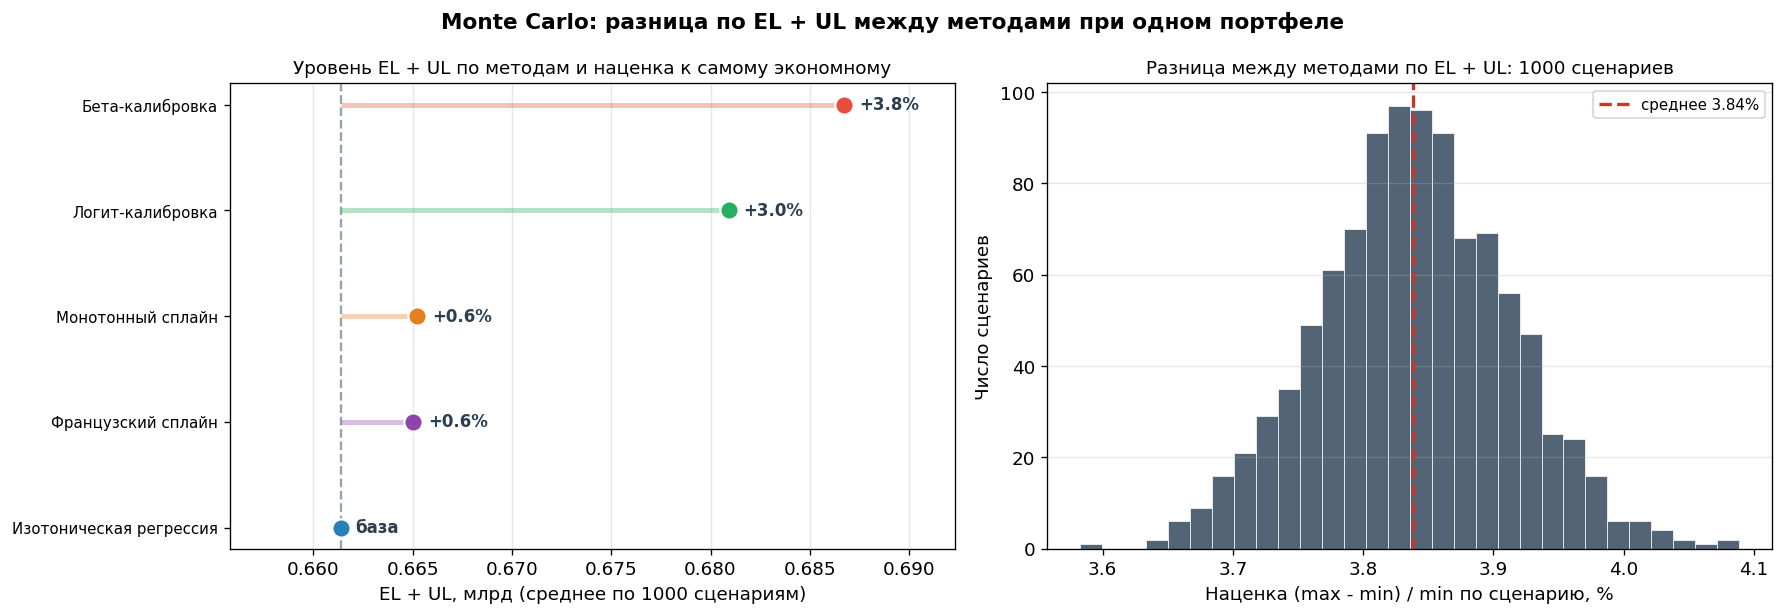

In [9]:
methods = list(summary["method"])
method_colors = {name: COLORS[i % len(COLORS)] for i, name in enumerate(methods)}

order = summary.sort_values("el_plus_ul_mean").reset_index(drop=True)
methods_sorted = order["method"].tolist()
levels_bln = order["el_plus_ul_mean"].to_numpy() / 1e9
cheapest = float(levels_bln.min())
markup = levels_bln / cheapest - 1.0

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))

# --- Панель А: уровень EL+UL по методам, наценка к самому экономному ---
ax = axes[0]
y = np.arange(len(methods_sorted))
ax.axvline(cheapest, color="#95a5a6", ls="--", lw=1.4, zorder=1)
for i, (name, lv, mk) in enumerate(zip(methods_sorted, levels_bln, markup)):
    ax.hlines(i, cheapest, lv, color=method_colors[name], lw=3, alpha=0.35, zorder=2)
    ax.scatter(lv, i, color=method_colors[name], s=120, zorder=5, edgecolor="white", linewidth=1.3)
    label = "база" if mk <= 1e-9 else f"+{mk:.1%}"
    ax.annotate(label, (lv, i), xytext=(9, 0), textcoords="offset points",
                va="center", ha="left", fontsize=10, fontweight="bold", color="#2c3e50")
ax.set_yticks(y)
ax.set_yticklabels(methods_sorted, fontsize=9)
ax.set_xlabel("EL + UL, млрд (среднее по 1000 сценариям)")
ax.set_title("Уровень EL + UL по методам и наценка к самому экономному", fontsize=11)
ax.margins(x=0.22)
ax.grid(axis="x", alpha=0.3)

# --- Панель Б: распределение межметодной наценки по 1000 сценариям ---
ax = axes[1]
rel = spread["rel_diff"].to_numpy() * 100.0
ax.hist(rel, bins=30, color="#34495e", alpha=0.85, edgecolor="white", linewidth=0.5)
mean_rel = float(rel.mean())
ax.axvline(mean_rel, color="#c0392b", ls="--", lw=2.0, label=f"среднее {mean_rel:.2f}%")
ax.set_xlabel("Наценка (max - min) / min по сценарию, %")
ax.set_ylabel("Число сценариев")
ax.set_title(f"Разница между методами по EL + UL: {len(rel)} сценариев", fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)

plt.suptitle("Monte Carlo: разница по EL + UL между методами при одном портфеле", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Интерпретация

- **Средний PD на OOT и денежные метрики (EL / UL / EL+UL / RWA) устойчивы**: разброс max-min — доли процента от уровня метрики. Выводы раздела 8 основного ноутбука не зависят от того, какие именно ~80% портфеля попали в выборку.
- **Межметодный разброс EL + UL внутри сценария невелик** (разделы 3a, 4): самый консервативный и самый экономный метод различаются на единицы процентов; выбор калибратора не переворачивает капитальную картину.
- **Как целые модели все пять откалиброваны правильно.** Whole-model тест само-калибровки (суммарный факт дефолтов против суммы предсказанных PD) проходят все методы и на IN-TIME, и на OOT, практически на всех сценариях (раздел 3b). Это ожидаемо: модели приведены к ЦТ и корректно оценивают суммарный уровень риска.
- **По-грейдовый тест против фиксированной мастер-шкалы — только диагностика** (раздел 3c), и его сырой вид перемощён. После поправки на множественность (Bonferroni) логит и бета проходят и его. У изотоники и сплайнов флаг остаётся, но это (а) грейд E, где midpoint ментора 40% занижает реальные ~48% портфеля, и (б) безопасный хвост B1, куда они кладут надёжных заёмщиков с прогнозом ~0.12%, а те на OOT дефолтят ~0.9% (заложенный OOT-сдвиг). На whole-model уровне это калибровку не ломает — суммарный PD и капитал у всех методов в норме.

**Про производительность.** RF-скоринг, по-строчный IRB-капитал и грейды мастер-шкалы предвычислены один раз в `prepare_fixed_pipeline`; сценарий только индексирует свою случайную ~80%-подвыборку и суммирует. 1000 ранов считаются за минуты.